FIRST 5 ROWS
   Order_ID  Distance_km Weather Traffic_Level Time_of_Day Vehicle_Type  \
0       522         7.93   Windy           Low   Afternoon      Scooter   
1       738        16.42   Clear        Medium     Evening         Bike   
2       741         9.52   Foggy           Low       Night      Scooter   
3       661         7.44   Rainy        Medium   Afternoon      Scooter   
4       412        19.03   Clear           Low     Morning         Bike   

   Preparation_Time_min  Courier_Experience_yrs  Delivery_Time_min  
0                    12                     1.0                 43  
1                    20                     2.0                 84  
2                    28                     1.0                 59  
3                     5                     1.0                 37  
4                    16                     5.0                 68  

DATASET INFORMATION
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 9 column

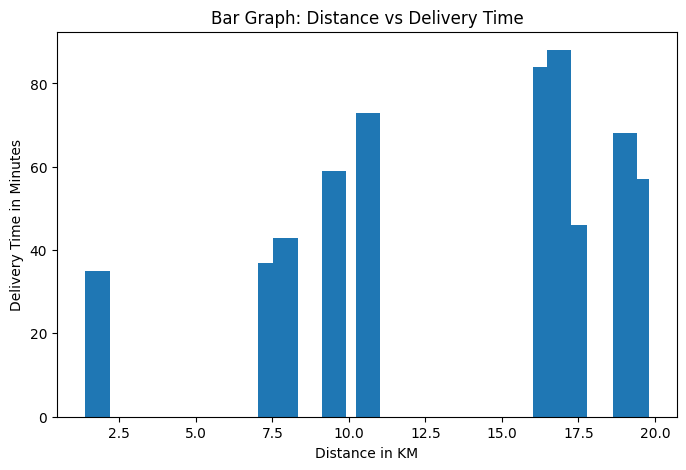

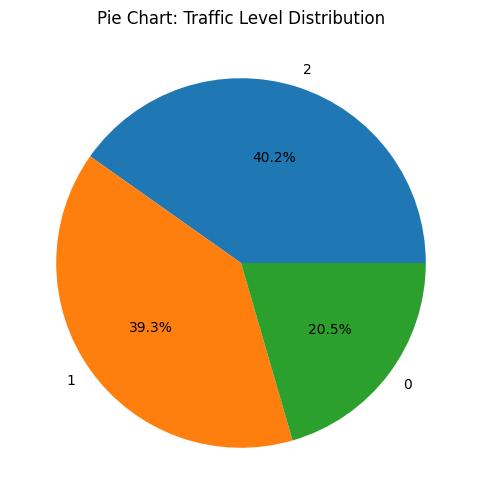


MODEL TRAINED SUCCESSFULLY

PREDICTED DELIVERY TIMES
[39.28 38.16 41.25 87.93 50.76]

MEAN ABSOLUTE ERROR
7.014463276836158

FINAL OUTPUT
Predicted Delivery Time: 41.86 minutes


/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but RandomForestRegressor was fitted with feature names
  warnings.warn(


In [4]:

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.preprocessing import LabelEncoder
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error

df = pd.read_csv('/content/Food_Delivery_Times.csv')
print("FIRST 5 ROWS")
print(df.head())
print("\nDATASET INFORMATION")
print(df.info())

print("\nMISSING VALUES")
print(df.isnull().sum())

print("\nDUPLICATE VALUES")
print(df.duplicated().sum())
df = df.dropna()
df = df.drop_duplicates()

print("\nDATASET CLEANED SUCCESSFULLY")
le = LabelEncoder()
df['Weather'] = le.fit_transform(df['Weather'])
df['Traffic_Level'] = le.fit_transform(df['Traffic_Level'])
df['Time_of_Day'] = le.fit_transform(df['Time_of_Day'])
df['Vehicle_Type'] = le.fit_transform(df['Vehicle_Type'])

plt.figure(figsize=(8,5))
plt.bar(
    df['Distance_km'][:10],
    df['Delivery_Time_min'][:10]
)
plt.xlabel("Distance in KM")
plt.ylabel("Delivery Time in Minutes")
plt.title("Bar Graph: Distance vs Delivery Time")
plt.show()

traffic_counts = df['Traffic_Level'].value_counts()
plt.figure(figsize=(6,6))
plt.pie(
    traffic_counts,
    labels=traffic_counts.index,
    autopct='%1.1f%%'
)
plt.title("Pie Chart: Traffic Level Distribution")
plt.show()
X = df[
    [
        'Distance_km',
        'Weather',
        'Traffic_Level',
        'Time_of_Day',
        'Vehicle_Type',
        'Preparation_Time_min',
        'Courier_Experience_yrs'
    ]
]
y = df['Delivery_Time_min']
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)
model = RandomForestRegressor()
model.fit(X_train, y_train)
print("\nMODEL TRAINED SUCCESSFULLY")
predictions = model.predict(X_test)
print("\nPREDICTED DELIVERY TIMES")
print(predictions[:5])
mae = mean_absolute_error(y_test, predictions)
print("\nMEAN ABSOLUTE ERROR")
print(mae)

sample = [[
    5.0,   # Distance_km
    1,     # Weather
    2,     # Traffic_Level
    1,     # Time_of_Day
    0,     # Vehicle_Type
    15,    # Preparation_Time_min
    3      # Courier_Experience_yrs
]]
result = model.predict(sample)
print("\nFINAL OUTPUT")
print("Predicted Delivery Time:", result[0], "minutes")
